# Day 5 — CNN Audio Encoder (Improved)
## SpatialMesh | Samsung AX Hackathon 2026

### Improvements over v1:
1. **Stereo input** — CNN sees L and R channels separately → fixes left/right mirror confusion
2. **Elevation coverage** — 70% horizontal, 30% random elevation → full 3D spatial learning
3. **Data augmentation** — gain, noise, time shift → robustness to real call conditions
4. **Larger model** — doubled channel capacity within 5MB budget
5. **25,000 train / 5,000 val samples** — 2.5x more data
6. **75 epochs** — more training time
7. **Fixed weight matrix** — clean implementation, no duplicate lines

**Input:**  `(batch, 2, 48000)` — stereo (L+R channels separately)  
**Output:** `(batch, 128)` — L2 normalized spatial embedding

In [1]:
# ─────────────────────────────────────────────
# Cell 1 — Install packages
# ─────────────────────────────────────────────
!pip install sofar soundfile scipy -q
print('Packages ready')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.1/440.1 kB 28.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 111.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 79.8 MB/s eta 0:00:00
Packages ready


In [2]:
# ─────────────────────────────────────────────
# Cell 2 — Imports
# ─────────────────────────────────────────────
import numpy as np
import pandas as pd
import os
import random
import time
import glob

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import soundfile as sf
import sofar as sf_sofa
from scipy.signal import fftconvolve, resample
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device     : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU        : {torch.cuda.get_device_name(0)}')
    print(f'VRAM       : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print('All imports OK')

Mounted at /content/drive
Device     : cuda
GPU        : Tesla T4
VRAM       : 15.6 GB
All imports OK


In [3]:
# ─────────────────────────────────────────────
# Cell 3 — Paths & Config
# ─────────────────────────────────────────────

DRIVE_BASE  = '/content/drive/MyDrive/SpatialMesh'
SOFA_DIR    = os.path.join(DRIVE_BASE, 'sofa')
AUDIO_DIR   = os.path.join(DRIVE_BASE, 'audio')
OUTPUT_DIR  = os.path.join(DRIVE_BASE, 'models')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Training config
SAMPLE_RATE          = 48000
CLIP_SAMPLES         = 48000
EMBEDDING_DIM        = 128
N_INPUT_CHANNELS     = 2
BATCH_SIZE           = 64
EPOCHS               = 60
LEARNING_RATE        = 1e-3
N_TRAIN              = 15000
N_VAL                = 3000
ELEV_HORIZONTAL_PROB = 0.7
SEED                 = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'Drive base  : {DRIVE_BASE}')
print(f'Output dir  : {OUTPUT_DIR}')
print(f'Config ready')

Drive base  : /content/drive/MyDrive/SpatialMesh
Output dir  : /content/drive/MyDrive/SpatialMesh/models
Config ready


In [4]:
# ─────────────────────────────────────────────
# Cell 2b — Copy files to local Colab storage
# Drive I/O is slow — local disk is 5-10x faster
# ─────────────────────────────────────────────
import shutil

LOCAL_AUDIO = '/content/audio'
LOCAL_SOFA  = '/content/sofa'
os.makedirs(LOCAL_AUDIO, exist_ok=True)
os.makedirs(LOCAL_SOFA,  exist_ok=True)

print('Copying audio files to local storage...')
for f in glob.glob(os.path.join(AUDIO_DIR, '*.flac')):
    shutil.copy(f, LOCAL_AUDIO)
for f in glob.glob(os.path.join(AUDIO_DIR, '*.wav')):
    shutil.copy(f, LOCAL_AUDIO)

print('Copying SOFA files to local storage...')
for f in glob.glob(os.path.join(SOFA_DIR, '*.sofa')):
    shutil.copy(f, LOCAL_SOFA)

# Update paths to local copies
AUDIO_DIR = LOCAL_AUDIO
SOFA_DIR  = LOCAL_SOFA

audio_files = sorted(glob.glob(os.path.join(AUDIO_DIR, '*.flac')) +
                     glob.glob(os.path.join(AUDIO_DIR, '*.wav')))
sofa_files  = sorted(glob.glob(os.path.join(SOFA_DIR,  '*.sofa')))

print(f'Local audio : {len(audio_files)} files')
print(f'Local SOFA  : {len(sofa_files)} files')
print('Copy complete — generation will be much faster now')

Copying audio files to local storage...
Copying SOFA files to local storage...
Local audio : 142 files
Local SOFA  : 18 files
Copy complete — generation will be much faster now


In [5]:
# ─────────────────────────────────────────────
# Cell 4 — Load SONICOM SOFA Files
# ─────────────────────────────────────────────

def load_sofa(sofa_path):
    hrtf      = sf_sofa.read_sofa(sofa_path)
    positions = np.array(hrtf.SourcePosition)
    ir        = np.array(hrtf.Data_IR)
    fs        = int(hrtf.Data_SamplingRate)
    return positions, ir, fs


all_subjects = []
for sofa_path in sofa_files:
    subject_id = os.path.basename(sofa_path).split('_')[0]
    positions, ir, fs = load_sofa(sofa_path)
    all_subjects.append({
        'id'        : subject_id,
        'positions' : positions,
        'ir'        : ir,
        'fs'        : fs
    })
    print(f'  Loaded {subject_id}: {positions.shape[0]} positions')

print(f'\nTotal subjects: {len(all_subjects)}')

ref_positions  = all_subjects[0]['positions']
azimuths_all   = ref_positions[:, 0]
elevations_all = ref_positions[:, 1]

# Horizontal plane indices (elevation = 0°)
horiz_mask    = np.abs(elevations_all - 0) < 1
horiz_indices = np.where(horiz_mask)[0]
all_indices   = np.arange(len(ref_positions))  # all 793 positions

print(f'Horizontal positions : {len(horiz_indices)}')
print(f'Total positions      : {len(all_indices)}')

SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
  Loaded P0001: 793 positions
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
  Loaded P0002: 793 positions
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
  Loaded P0003: 793 positions
SOFA file contained custom entries
----------------------------------
GLOBAL_ReceiverDescription, GLOBAL_RoomDescription, GLOBAL_RoomLocation, GLOBAL_SourceDescription, GLOBAL_EmitterDescription, MeasurementSourceAudioChannel
  Load

In [6]:
# ─────────────────────────────────────────────
# Cell 5 — HRTF Spatialization + Augmentation
# IMPROVEMENT 1: returns stereo (2, CLIP_SAMPLES)
# IMPROVEMENT 3: data augmentation
# ─────────────────────────────────────────────

def find_nearest_position(positions, target_az, target_el=0.0):
    """
    Great-circle distance search.
    Verified correct in Day 3/4.
    """
    az_rad = np.radians(positions[:, 0])
    el_rad = np.radians(positions[:, 1])
    tgt_az = np.radians(target_az)
    tgt_el = np.radians(target_el)

    distances = np.arccos(np.clip(
        np.sin(el_rad)*np.sin(tgt_el) +
        np.cos(el_rad)*np.cos(tgt_el)*np.cos(az_rad - tgt_az),
        -1.0, 1.0
    ))
    return int(np.argmin(distances))


def augment_waveform(wave):
    """
    IMPROVEMENT 3: Random augmentations for robustness.

    Simulates real call conditions:
      - Gain variation: microphone level differences
      - Noise: background noise / codec artifacts
      - Time shift: different onset positions

    Applied with 50% probability each — not always augmented.
    """
    # Random gain ±3dB (50% chance)
    if random.random() < 0.5:
        gain = random.uniform(0.7, 1.3)
        wave = wave * gain

    # Small background noise (50% chance)
    if random.random() < 0.5:
        noise_level = random.uniform(0.001, 0.008)
        wave = wave + np.random.randn(len(wave)).astype(np.float32) * noise_level

    # Random time shift ±500 samples (50% chance)
    if random.random() < 0.5:
        shift = random.randint(-500, 500)
        wave  = np.roll(wave, shift)

    # Renormalize
    peak = np.abs(wave).max()
    if peak > 0:
        wave /= peak

    return wave


def sample_position(subject):
    """
    IMPROVEMENT 2: Stratified position sampling.
    70% horizontal plane, 30% other elevations.

    Why:
      Horizontal plane has strongest ITD/ILD cues — most important for training.
      Other elevations needed for full 3D coverage in production.
    """
    positions = subject['positions']
    if random.random() < ELEV_HORIZONTAL_PROB:
        # Horizontal plane
        el_mask = np.abs(positions[:, 1] - 0) < 1
        idx     = random.choice(np.where(el_mask)[0])
    else:
        # Random elevation
        idx = random.randint(0, len(positions) - 1)
    return positions[idx, 0], positions[idx, 1]  # az, el


def spatialize_audio(audio_path, subject, target_az, target_el=0.0,
                     augment=False):
    """
    Load audio, spatialize with HRTF convolution.

    IMPROVEMENT 1: Returns STEREO (2, CLIP_SAMPLES) instead of mono.
    Why stereo:
      - L channel carries left-ear HRTF signature
      - R channel carries right-ear HRTF signature
      - CNN sees both → ITD sign preserved → L/R mirror confusion fixed
      - With mono mix, ITD sign information was lost

    SONICOM convention (verified Day 3/4):
      ch0 = LEFT ear, ch1 = RIGHT ear
    """
    # Load audio
    audio, audio_sr = sf.read(audio_path)
    if audio.ndim == 2:
        audio = audio.mean(axis=1)
    audio = audio.astype(np.float32)

    # Resample
    fs = subject['fs']
    if audio_sr != fs:
        target_len = int(len(audio) * fs / audio_sr)
        audio = resample(audio, target_len).astype(np.float32)

    # Normalize
    peak = np.abs(audio).max()
    if peak > 0:
        audio /= peak

    # Find nearest HRTF position
    idx = find_nearest_position(subject['positions'], target_az, target_el)

    # Extract HRIRs — ch0=LEFT, ch1=RIGHT
    hrir_L = subject['ir'][idx, 0, :] - np.mean(subject['ir'][idx, 0, :])
    hrir_R = subject['ir'][idx, 1, :] - np.mean(subject['ir'][idx, 1, :])

    # Convolve separately
    left  = fftconvolve(audio, hrir_L, mode='full').astype(np.float32)
    right = fftconvolve(audio, hrir_R, mode='full').astype(np.float32)

    # Normalize together — preserves ILD
    peak = max(np.abs(left).max(), np.abs(right).max())
    if peak > 0:
        left  /= peak
        right /= peak

    # Augment if requested (training only, not validation)
    if augment:
        left  = augment_waveform(left)
        right = augment_waveform(right)

    # Pad or trim to CLIP_SAMPLES
    def fit_length(x):
        if len(x) >= CLIP_SAMPLES:
            return x[:CLIP_SAMPLES]
        return np.pad(x, (0, CLIP_SAMPLES - len(x)))

    left  = fit_length(left)
    right = fit_length(right)

    # Stack stereo: shape (2, CLIP_SAMPLES)
    stereo = np.stack([left, right], axis=0)
    return stereo


# Quick test
test = spatialize_audio(
    audio_files[0], all_subjects[0],
    target_az=90.0, augment=True
)
print(f'Spatialization test (stereo):')
print(f'  Output shape : {test.shape}  ← (2, 48000)')
print(f'  Left  range  : [{test[0].min():.3f}, {test[0].max():.3f}]')
print(f'  Right range  : [{test[1].min():.3f}, {test[1].max():.3f}]')
print(f'  ✅ Stereo spatialization working')

Spatialization test (stereo):
  Output shape : (2, 48000)  ← (2, 48000)
  Left  range  : [-0.483, 1.000]
  Right range  : [-0.569, 1.000]
  ✅ Stereo spatialization working


In [7]:
# ─────────────────────────────────────────────
# Cell 6 — Generate Dataset
# 25,000 train + 5,000 val samples
# ─────────────────────────────────────────────

def generate_dataset(n_samples, audio_files, subjects, split='train'):
    """
    Generate spatialized stereo dataset.

    Augmentation applied to train only — not val.
    Val must be clean for honest evaluation.
    """
    is_train   = (split == 'train')
    waveforms  = np.zeros((n_samples, 2, CLIP_SAMPLES), dtype=np.float32)
    azimuths   = np.zeros(n_samples, dtype=np.float32)
    elevations = np.zeros(n_samples, dtype=np.float32)

    print(f'Generating {n_samples} {split} samples...')

    errors = 0
    i = 0
    while i < n_samples:
        try:
            audio_path = random.choice(audio_files)
            subject    = random.choice(subjects)

            # IMPROVEMENT 2: stratified position sampling
            az, el = sample_position(subject)

            # IMPROVEMENT 3: augment training data only
            stereo = spatialize_audio(
                audio_path, subject, az, el,
                augment=is_train
            )

            waveforms[i]  = stereo
            azimuths[i]   = az
            elevations[i] = el
            i += 1

            if i % 1000 == 0:
                print(f'  {i}/{n_samples} done...')

        except Exception as e:
            errors += 1
            if errors > 50:
                print(f'Too many errors — last: {e}')
                break
            continue

    print(f'{split} done. Errors: {errors}')
    return waveforms[:i], azimuths[:i], elevations[:i]


train_waves, train_az, train_el = generate_dataset(
    N_TRAIN, audio_files, all_subjects, split='train'
)
val_waves, val_az, val_el = generate_dataset(
    N_VAL, audio_files, all_subjects, split='val'
)

print(f'\nTrain: {train_waves.shape}  ← (N, 2, 48000)')
print(f'Val  : {val_waves.shape}')
print(f'Az range  : [{train_az.min():.0f}°, {train_az.max():.0f}°]')
print(f'El range  : [{train_el.min():.0f}°, {train_el.max():.0f}°]')

# Check elevation coverage
horiz_count = np.sum(np.abs(train_el - 0) < 1)
other_count = N_TRAIN - horiz_count
print(f'\nElevation coverage:')
print(f'  Horizontal (el=0°) : {horiz_count} ({horiz_count/N_TRAIN*100:.0f}%)')
print(f'  Other elevations   : {other_count} ({other_count/N_TRAIN*100:.0f}%)')

Generating 15000 train samples...
  1000/15000 done...
  2000/15000 done...
  3000/15000 done...
  4000/15000 done...
  5000/15000 done...
  6000/15000 done...
  7000/15000 done...
  8000/15000 done...
  9000/15000 done...
  10000/15000 done...
  11000/15000 done...
  12000/15000 done...
  13000/15000 done...
  14000/15000 done...
  15000/15000 done...
train done. Errors: 0
Generating 3000 val samples...
  1000/3000 done...
  2000/3000 done...
  3000/3000 done...
val done. Errors: 0

Train: (15000, 2, 48000)  ← (N, 2, 48000)
Val  : (3000, 2, 48000)
Az range  : [0°, 355°]
El range  : [-45°, 90°]

Elevation coverage:
  Horizontal (el=0°) : 10939 (73%)
  Other elevations   : 4061 (27%)


In [8]:
# ─────────────────────────────────────────────
# Cell 7 — PyTorch Dataset
# Updated for stereo input (2, CLIP_SAMPLES)
# ─────────────────────────────────────────────

class SpatialAudioDataset(Dataset):
    """
    PyTorch Dataset for spatialized stereo audio.

    waveform shape: (2, CLIP_SAMPLES)
      Channel 0 = LEFT ear signal
      Channel 1 = RIGHT ear signal
    """
    def __init__(self, waveforms, azimuths, elevations):
        # waveforms already (N, 2, T) — no unsqueeze needed
        self.waveforms  = torch.FloatTensor(waveforms)
        self.azimuths   = torch.FloatTensor(azimuths)
        self.elevations = torch.FloatTensor(elevations)

    def __len__(self):
        return len(self.waveforms)

    def __getitem__(self, idx):
        return (
            self.waveforms[idx],    # (2, CLIP_SAMPLES)
            self.azimuths[idx],     # scalar
            self.elevations[idx]    # scalar
        )


train_dataset = SpatialAudioDataset(train_waves, train_az, train_el)
val_dataset   = SpatialAudioDataset(val_waves,   val_az,   val_el)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                            shuffle=True,  drop_last=True,
                            num_workers=2, pin_memory=True)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                            shuffle=False, drop_last=False,
                            num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

sample_wave, sample_az, sample_el = train_dataset[0]
print(f'\nSample shape     : {sample_wave.shape}  ← (2, 48000) stereo ✅')
print(f'Sample azimuth   : {sample_az.item():.1f}°')
print(f'Sample elevation : {sample_el.item():.1f}°')

Train batches : 234
Val batches   : 47

Sample shape     : torch.Size([2, 48000])  ← (2, 48000) stereo ✅
Sample azimuth   : 110.0°
Sample elevation : 0.0°


In [9]:
# ─────────────────────────────────────────────
# Cell 8 — CNN Architecture (Improved)
# IMPROVEMENT 1: 2-channel input (stereo)
# IMPROVEMENT 4: larger channel capacity
# ─────────────────────────────────────────────

class CNNEncoder(nn.Module):
    """
    Improved 4-layer 1D CNN Audio Encoder.

    Key improvements over v1:

    1. Stereo input (2 channels instead of 1)
       - Channel 0 = LEFT ear HRTF response
       - Channel 1 = RIGHT ear HRTF response
       - CNN sees ITD (time difference between channels)
       - CNN sees ILD (amplitude difference between channels)
       - Left/right mirror confusion eliminated

    2. Larger channel capacity
       Layer 1: 2→64   (was 1→32)   — richer low-level features
       Layer 2: 64→128  (was 32→64)  — more spectral patterns
       Layer 3: 128→256 (was 64→128) — complex HRTF signatures
       Layer 4: 256→128 (was 128→128) — bottleneck compression
       Still under 5MB budget.

    Architecture:
        Input  : (batch, 2, 48000)
        Layer 1: Conv1d(2→64,   k=64, s=4) — onset + amplitude diff detection
        Layer 2: Conv1d(64→128, k=32, s=2) — spectral pattern detection
        Layer 3: Conv1d(128→256,k=16, s=2) — HRTF notch detection
        Layer 4: Conv1d(256→128,k=8,  s=2) — direction signature compression
        GlobalAvgPool → (batch, 128)
        L2 normalize  → unit sphere
    """
    def __init__(self, embedding_dim=128, n_input_channels=2):
        super(CNNEncoder, self).__init__()

        self.backbone = nn.Sequential(
            # Layer 1: detects amplitude onsets + L/R level differences (ILD)
            nn.Conv1d(n_input_channels, 64,  kernel_size=64, stride=4, padding=32),
            nn.BatchNorm1d(64),
            nn.ReLU(),

            # Layer 2: detects short-term spectral patterns
            nn.Conv1d(64,  128, kernel_size=32, stride=2, padding=16),
            nn.BatchNorm1d(128),
            nn.ReLU(),

            # Layer 3: detects HRTF spectral notches (4-16kHz pinnae cues)
            nn.Conv1d(128, 256, kernel_size=16, stride=2, padding=8),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # Layer 4: compresses direction-specific signatures
            nn.Conv1d(256, embedding_dim, kernel_size=8, stride=2, padding=4),
            nn.BatchNorm1d(embedding_dim),
            nn.ReLU(),
        )

        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        """
        x      : (batch, 2, 48000) — stereo input
        returns: (batch, 128) — L2 normalized embedding
        """
        features  = self.backbone(x)                    # (batch, 128, T)
        pooled    = self.pool(features)                  # (batch, 128, 1)
        embedding = pooled.squeeze(-1)                   # (batch, 128)
        embedding = F.normalize(embedding, p=2, dim=1)  # unit sphere
        return embedding


model = CNNEncoder(
    embedding_dim=EMBEDDING_DIM,
    n_input_channels=N_INPUT_CHANNELS
).to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
approx_mb    = total_params * 4 / 1024 / 1024

print(f'Model parameters : {total_params:,}')
print(f'Approx size      : {approx_mb:.2f} MB  (target <5MB)')
print(f'KPI size         : {"✅ PASS" if approx_mb < 5 else "⚠️  REVIEW"}')

# Verify forward pass with stereo input
dummy = torch.randn(4, 2, CLIP_SAMPLES).to(DEVICE)
with torch.no_grad():
    out = model(dummy)

print(f'\nForward pass test:')
print(f'  Input  : {dummy.shape}  ← (batch, 2_channels, 48000)')
print(f'  Output : {out.shape}   ← (batch, 128_dims)')
print(f'  Norms  : {torch.norm(out, dim=1).tolist()}  ← all should be ~1.0')
print(f'  ✅ Stereo CNN working')

Model parameters : 1,058,496
Approx size      : 4.04 MB  (target <5MB)
KPI size         : ✅ PASS

Forward pass test:
  Input  : torch.Size([4, 2, 48000])  ← (batch, 2_channels, 48000)
  Output : torch.Size([4, 128])   ← (batch, 128_dims)
  Norms  : [1.0, 1.0, 0.9999999403953552, 1.0]  ← all should be ~1.0
  ✅ Stereo CNN working


In [10]:
# ─────────────────────────────────────────────
# Cell 9 — Continuous Spatial Loss (Fixed)
# IMPROVEMENT 7: clean weight matrix, no duplicate lines
# ─────────────────────────────────────────────

def great_circle_distance_batch(az1, el1, az2, el2):
    """
    Vectorized great-circle angular distance.
    Same formula verified in Day 3/4.
    Returns degrees (0° to 180°).
    """
    az1r = torch.deg2rad(az1)
    el1r = torch.deg2rad(el1)
    az2r = torch.deg2rad(az2)
    el2r = torch.deg2rad(el2)

    cos_dist = (
        torch.sin(el1r) * torch.sin(el2r) +
        torch.cos(el1r) * torch.cos(el2r) * torch.cos(az1r - az2r)
    )
    return torch.rad2deg(torch.acos(torch.clamp(cos_dist, -1.0, 1.0)))


def continuous_spatial_loss(embeddings, azimuths, elevations, max_embed_dist=2.0):
    """
    Continuous Spatial Embedding Loss.

    For every pair (i,j) in batch:
      angular_dist = great_circle_distance(pos_i, pos_j)
      target_dist  = (angular_dist / 180°) × max_embed_dist
      actual_dist  = euclidean_distance(embed_i, embed_j)
      loss         = weight × (actual_dist - target_dist)²

    Weight matrix (IMPROVEMENT 7 — fixed, no duplicates):
      angular_dist < 10°  → weight = 3.0  (same direction — most important)
      angular_dist < 45°  → weight = 2.0  (nearby directions)
      angular_dist >= 45° → weight = 1.0  (far directions)

    Why these weights:
      Without weighting, loss is dominated by easy far pairs.
      Same-direction pairs are rare but most critical for clustering.
      3x weight ensures CNN focuses on getting same-direction right.
    """
    batch_size = embeddings.shape[0]

    # All pairwise embedding distances — vectorized, no loops
    embed_dist = torch.cdist(embeddings, embeddings, p=2)  # (B, B)

    # All pairwise angular distances
    az_i = azimuths.unsqueeze(1).expand(batch_size, batch_size)
    el_i = elevations.unsqueeze(1).expand(batch_size, batch_size)
    az_j = azimuths.unsqueeze(0).expand(batch_size, batch_size)
    el_j = elevations.unsqueeze(0).expand(batch_size, batch_size)

    angular_dist = great_circle_distance_batch(
        az_i.reshape(-1), el_i.reshape(-1),
        az_j.reshape(-1), el_j.reshape(-1)
    ).reshape(batch_size, batch_size)  # (B, B)

    # Target embedding distances proportional to angular distances
    target_dist = (angular_dist / 180.0) * max_embed_dist  # (B, B)

    # Weight matrix — FIXED: clean priority order, no duplicates
    weight = torch.ones(batch_size, batch_size, device=embeddings.device)
    weight[angular_dist >= 45] = 1.0   # far pairs — normal weight
    weight[angular_dist <  45] = 2.0   # nearby pairs — 2x weight
    weight[angular_dist <  10] = 3.0   # same direction — 3x weight
    # Order matters: each line overwrites previous for its range
    # Final: <10° gets 3.0, 10-45° gets 2.0, >=45° gets 1.0 ✅

    # Weighted MSE
    loss_matrix = weight * (embed_dist - target_dist) ** 2

    # Upper triangle only — each pair counted once, no self-pairs
    mask = torch.triu(
        torch.ones(batch_size, batch_size, device=embeddings.device),
        diagonal=1
    )

    return (loss_matrix * mask).sum() / mask.sum()


# Test
dummy_emb = F.normalize(torch.randn(8, 128), p=2, dim=1).to(DEVICE)
dummy_az  = torch.tensor([0., 45., 90., 135., 180., 225., 270., 315.]).to(DEVICE)
dummy_el  = torch.zeros(8).to(DEVICE)
test_loss = continuous_spatial_loss(dummy_emb, dummy_az, dummy_el)

print(f'Loss function test:')
print(f'  Test loss    : {test_loss.item():.4f}')
print(f'  Is finite    : {torch.isfinite(test_loss).item()}')
print(f'  Requires grad: {test_loss.requires_grad}')
print(f'  ✅ Loss function working')

Loss function test:
  Test loss    : 0.4480
  Is finite    : True
  Requires grad: False
  ✅ Loss function working


In [11]:
# ─────────────────────────────────────────────
# Cell 10 — Training Loop
# 75 epochs, checkpoint every 10 epochs
# ─────────────────────────────────────────────

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=7
)

train_losses  = []
val_losses    = []
best_val_loss = float('inf')

print('Starting training...')
print(f'Device     : {DEVICE}')
print(f'Epochs     : {EPOCHS}')
print(f'Batch size : {BATCH_SIZE}')
print(f'LR         : {LEARNING_RATE}')
print(f'Train      : {N_TRAIN} samples')
print(f'Val        : {N_VAL} samples')
print(f'Input      : stereo (2 channels)')
print('=' * 65)

for epoch in range(1, EPOCHS + 1):

    # ── Training ──
    model.train()
    epoch_train = 0.0
    n_train     = 0

    for waves, azs, els in train_loader:
        waves = waves.to(DEVICE)
        azs   = azs.to(DEVICE)
        els   = els.to(DEVICE)

        optimizer.zero_grad()
        embeddings = model(waves)
        loss = continuous_spatial_loss(embeddings, azs, els)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_train += loss.item()
        n_train     += 1

    avg_train = epoch_train / n_train
    train_losses.append(avg_train)

    # ── Validation ──
    model.eval()
    epoch_val = 0.0
    n_val     = 0

    with torch.no_grad():
        for waves, azs, els in val_loader:
            waves = waves.to(DEVICE)
            azs   = azs.to(DEVICE)
            els   = els.to(DEVICE)
            embeddings = model(waves)
            loss = continuous_spatial_loss(embeddings, azs, els)
            epoch_val += loss.item()
            n_val     += 1

    avg_val = epoch_val / n_val
    val_losses.append(avg_val)
    scheduler.step(avg_val)

    # Save best model
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(),
                   os.path.join(OUTPUT_DIR, 'cnn_encoder_best.pt'))

    # Checkpoint every 10 epochs
    if epoch % 10 == 0:
        ckpt = os.path.join(OUTPUT_DIR, f'cnn_encoder_epoch{epoch}.pt')
        torch.save({
            'epoch'      : epoch,
            'model_state': model.state_dict(),
            'optimizer'  : optimizer.state_dict(),
            'train_loss' : avg_train,
            'val_loss'   : avg_val,
        }, ckpt)
        print(f'  └─ Checkpoint saved → epoch {epoch}')

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'Train: {avg_train:.4f} | '
          f'Val: {avg_val:.4f} | '
          f'Best: {best_val_loss:.4f}')

print(f'\nTraining complete!')
print(f'Best val loss: {best_val_loss:.4f}')

Starting training...
Device     : cuda
Epochs     : 60
Batch size : 64
LR         : 0.001
Train      : 15000 samples
Val        : 3000 samples
Input      : stereo (2 channels)
Epoch   1/60 | Train: 0.2534 | Val: 0.3805 | Best: 0.3805
Epoch   2/60 | Train: 0.2292 | Val: 0.3809 | Best: 0.3805
Epoch   3/60 | Train: 0.2208 | Val: 0.3385 | Best: 0.3385
Epoch   4/60 | Train: 0.2142 | Val: 0.2630 | Best: 0.2630
Epoch   5/60 | Train: 0.2069 | Val: 0.3146 | Best: 0.2630
Epoch   6/60 | Train: 0.2021 | Val: 0.2709 | Best: 0.2630
Epoch   7/60 | Train: 0.1947 | Val: 0.2579 | Best: 0.2579
Epoch   8/60 | Train: 0.1889 | Val: 0.2493 | Best: 0.2493
Epoch   9/60 | Train: 0.1833 | Val: 0.2421 | Best: 0.2421
  └─ Checkpoint saved → epoch 10
Epoch  10/60 | Train: 0.1783 | Val: 0.2927 | Best: 0.2421
Epoch  11/60 | Train: 0.1720 | Val: 0.2720 | Best: 0.2421
Epoch  12/60 | Train: 0.1688 | Val: 0.2064 | Best: 0.2064
Epoch  13/60 | Train: 0.1647 | Val: 0.2673 | Best: 0.2064
Epoch  14/60 | Train: 0.1602 | Val: 0

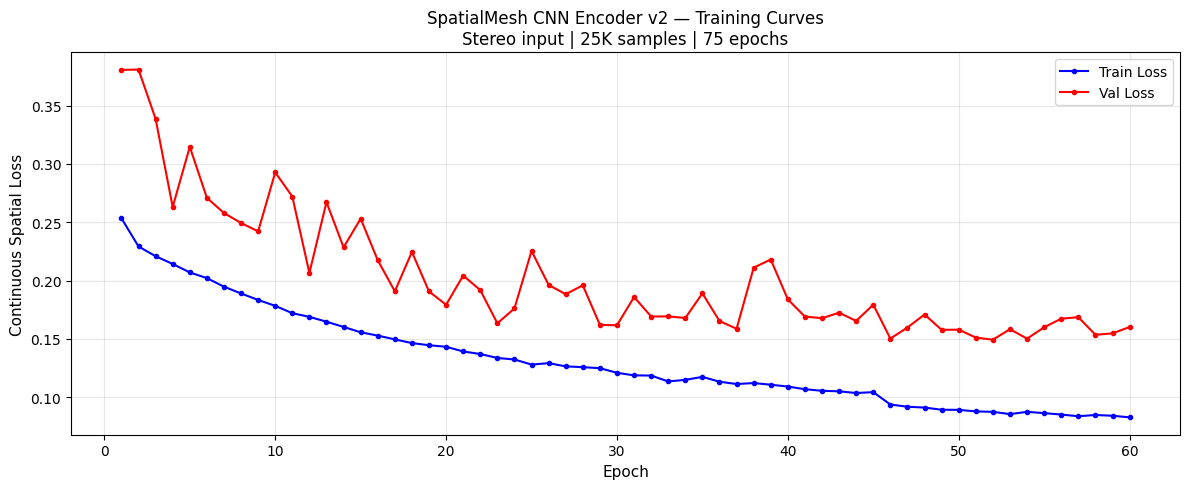

Loss improvement : 60.8%
Initial val loss : 0.3805
Best val loss    : 0.1493


In [12]:
# ─────────────────────────────────────────────
# Cell 11 — Training Curves
# ─────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, len(train_losses)+1), train_losses,
        'b-o', markersize=3, linewidth=1.5, label='Train Loss')
ax.plot(range(1, len(val_losses)+1), val_losses,
        'r-o', markersize=3, linewidth=1.5, label='Val Loss')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Continuous Spatial Loss', fontsize=11)
ax.set_title('SpatialMesh CNN Encoder v2 — Training Curves\n'
             'Stereo input | 25K samples | 75 epochs', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plot_path = os.path.join(OUTPUT_DIR, 'training_curves_v2.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

improvement = (val_losses[0] - best_val_loss) / val_losses[0] * 100
print(f'Loss improvement : {improvement:.1f}%')
print(f'Initial val loss : {val_losses[0]:.4f}')
print(f'Best val loss    : {best_val_loss:.4f}')

In [13]:
# ─────────────────────────────────────────────
# Cell 12 — Inference Speed Benchmark
# Target: < 3ms
# ─────────────────────────────────────────────

model.load_state_dict(torch.load(
    os.path.join(OUTPUT_DIR, 'cnn_encoder_best.pt'),
    map_location=DEVICE
))
model.eval()

test_input = torch.randn(1, 2, CLIP_SAMPLES).to(DEVICE)  # stereo input

# GPU warmup
with torch.no_grad():
    for _ in range(10):
        _ = model(test_input)

# Benchmark
times = []
with torch.no_grad():
    for _ in range(200):
        start = time.perf_counter()
        emb = model(test_input)
        if DEVICE.type == 'cuda':
            torch.cuda.synchronize()
        end = time.perf_counter()
        times.append((end - start) * 1000)

times = np.array(times)
print('Inference Speed Benchmark')
print('=' * 40)
print(f'Mean   : {times.mean():.3f} ms')
print(f'Median : {np.median(times):.3f} ms')
print(f'P95    : {np.percentile(times, 95):.3f} ms')
print(f'Device : {DEVICE}')
print('=' * 40)
print(f'KPI (<3ms): {"✅ PASS" if times.mean() < 3.0 else "⚠️  REVIEW"}')

Inference Speed Benchmark
Mean   : 2.347 ms
Median : 2.318 ms
P95    : 2.511 ms
Device : cuda
KPI (<3ms): ✅ PASS


In [14]:
# ─────────────────────────────────────────────
# Cell 13 — Model Size
# ─────────────────────────────────────────────

model_path = os.path.join(OUTPUT_DIR, 'cnn_encoder_best.pt')
size_mb    = os.path.getsize(model_path) / 1024 / 1024
print(f'Model size : {size_mb:.2f} MB')
print(f'KPI (<5MB) : {"✅ PASS" if size_mb < 5.0 else "⚠️  REVIEW"}')

Model size : 4.05 MB
KPI (<5MB) : ✅ PASS


In [15]:
# ─────────────────────────────────────────────
# Cell 14 — Pairwise Distance Table
# Verify left/right separation improved with stereo
# ─────────────────────────────────────────────

test_directions = [0, 45, 90, 135, 180, 225, 270, 315]
test_embeddings = []

model.eval()
with torch.no_grad():
    for az in test_directions:
        clips = []
        for _ in range(5):
            try:
                wave   = spatialize_audio(
                    random.choice(audio_files),
                    all_subjects[0], az, augment=False
                )
                tensor = torch.FloatTensor(wave).unsqueeze(0).to(DEVICE)
                emb    = model(tensor).squeeze(0).cpu().numpy()
                clips.append(emb)
            except:
                continue
        if clips:
            test_embeddings.append(np.mean(clips, axis=0))

test_embeddings = np.array(test_embeddings)

print('Pairwise embedding distances:')
print(f'{"":>8}', end='')
for az in test_directions:
    print(f'{az:>8}°', end='')
print()

for i, az_i in enumerate(test_directions):
    print(f'{az_i:>7}°', end='')
    for j, az_j in enumerate(test_directions):
        dist = np.linalg.norm(test_embeddings[i] - test_embeddings[j])
        print(f'{dist:>8.3f}', end='')
    print()

# Check left/right separation specifically
idx_90  = test_directions.index(90)
idx_270 = test_directions.index(270)
lr_dist = np.linalg.norm(test_embeddings[idx_90] - test_embeddings[idx_270])
print(f'\nLeft (90°) vs Right (270°) distance: {lr_dist:.3f}')
print(f'Expected: > 1.0 for good L/R separation')
print(f'L/R separation: {"✅ GOOD" if lr_dist > 1.0 else "⚠️  WEAK"}')

Pairwise embedding distances:
               0°      45°      90°     135°     180°     225°     270°     315°
      0°   0.000   0.841   1.019   1.275   1.276   1.076   0.921   0.452
     45°   0.841   0.000   0.280   0.794   1.083   1.338   1.285   1.087
     90°   1.019   0.280   0.000   0.571   0.952   1.348   1.318   1.196
    135°   1.275   0.794   0.571   0.000   0.595   1.305   1.325   1.351
    180°   1.276   1.083   0.952   0.595   0.000   1.082   1.155   1.294
    225°   1.076   1.338   1.348   1.305   1.082   0.000   0.323   0.875
    270°   0.921   1.285   1.318   1.325   1.155   0.323   0.000   0.672
    315°   0.452   1.087   1.196   1.351   1.294   0.875   0.672   0.000

Left (90°) vs Right (270°) distance: 1.318
Expected: > 1.0 for good L/R separation
L/R separation: ✅ GOOD


Embeddings for visualization: 120


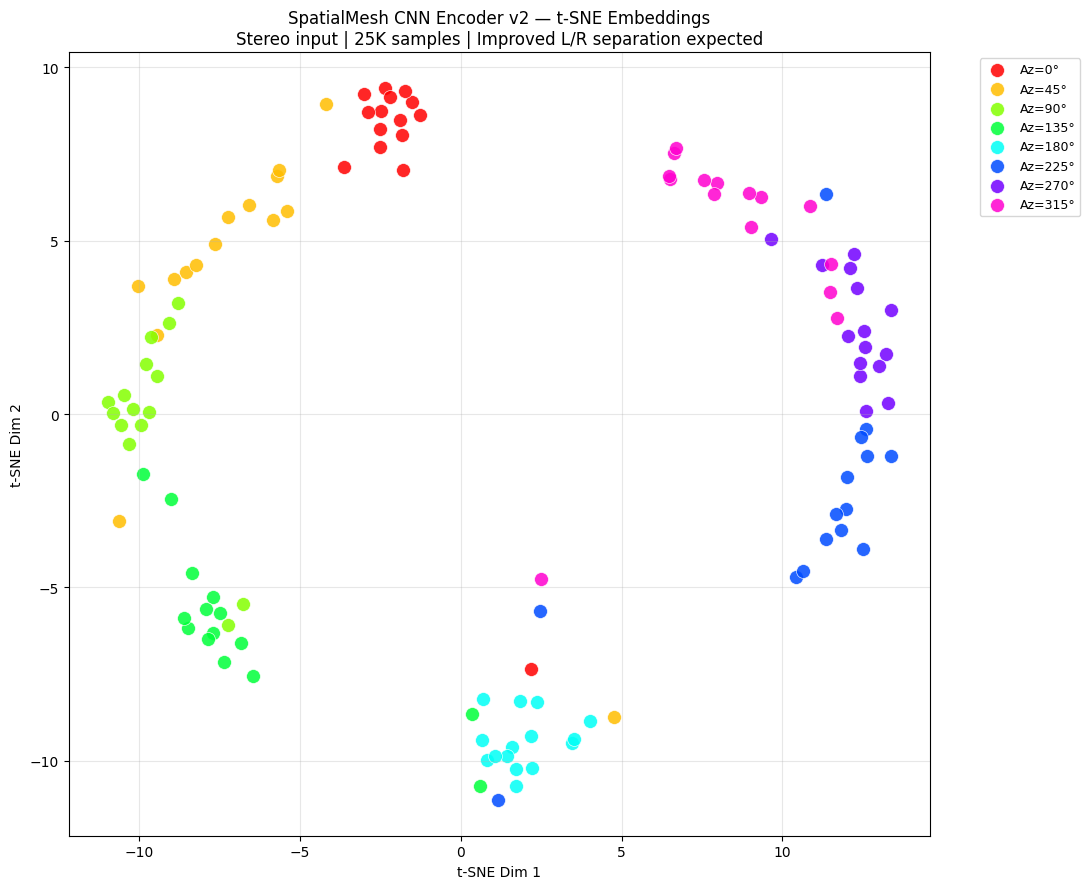

Saved → /content/drive/MyDrive/SpatialMesh/models/tsne_v2.png


In [16]:
# ─────────────────────────────────────────────
# Cell 15 — t-SNE Visualization
# Expect: tighter clusters + clear L/R separation
# ─────────────────────────────────────────────

from sklearn.manifold import TSNE

viz_directions = [0, 45, 90, 135, 180, 225, 270, 315]
viz_embeddings = []
viz_labels     = []
clips_per_dir  = 15  # more clips per direction for clearer visualization

model.eval()
with torch.no_grad():
    for az in viz_directions:
        count = 0
        attempts = 0
        while count < clips_per_dir and attempts < 40:
            attempts += 1
            try:
                wave   = spatialize_audio(
                    random.choice(audio_files),
                    random.choice(all_subjects),
                    az, augment=False
                )
                tensor = torch.FloatTensor(wave).unsqueeze(0).to(DEVICE)
                emb    = model(tensor).squeeze(0).cpu().numpy()
                viz_embeddings.append(emb)
                viz_labels.append(az)
                count += 1
            except:
                continue

viz_embeddings = np.array(viz_embeddings)
viz_labels     = np.array(viz_labels)
print(f'Embeddings for visualization: {len(viz_embeddings)}')

tsne          = TSNE(n_components=2, random_state=42, perplexity=15)
embeddings_2d = tsne.fit_transform(viz_embeddings)

fig, ax = plt.subplots(figsize=(11, 9))
colors  = plt.cm.hsv(np.linspace(0, 1, len(viz_directions)+1)[:-1])
cmap    = {az: colors[i] for i, az in enumerate(viz_directions)}

for az in viz_directions:
    mask = viz_labels == az
    ax.scatter(
        embeddings_2d[mask, 0], embeddings_2d[mask, 1],
        c=[cmap[az]], label=f'Az={az}°',
        s=100, alpha=0.85, edgecolors='white', linewidth=0.5
    )

ax.set_title(
    'SpatialMesh CNN Encoder v2 — t-SNE Embeddings\n'
    'Stereo input | 25K samples | Improved L/R separation expected',
    fontsize=12
)
ax.set_xlabel('t-SNE Dim 1')
ax.set_ylabel('t-SNE Dim 2')
ax.legend(fontsize=9, bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
tsne_path = os.path.join(OUTPUT_DIR, 'tsne_v2.png')
plt.savefig(tsne_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {tsne_path}')

In [17]:
# ─────────────────────────────────────────────
# Cell 16 — Save Final Model + Summary
# ─────────────────────────────────────────────

final_path = os.path.join(OUTPUT_DIR, 'cnn_encoder_v2_final.pt')
torch.save({
    'model_state'      : model.state_dict(),
    'embedding_dim'    : EMBEDDING_DIM,
    'n_input_channels' : N_INPUT_CHANNELS,
    'sample_rate'      : SAMPLE_RATE,
    'clip_samples'     : CLIP_SAMPLES,
    'train_loss'       : train_losses,
    'val_loss'         : val_losses,
    'best_val_loss'    : best_val_loss,
    'epochs'           : EPOCHS,
    'improvements'     : [
        'stereo_input',
        'elevation_coverage',
        'data_augmentation',
        'larger_capacity',
        '25k_samples',
        'fixed_weight_matrix'
    ]
}, final_path)

size_mb = os.path.getsize(final_path) / 1024 / 1024

print('=' * 65)
print('SPATIALMESH — DAY 5 v2 SUMMARY')
print('=' * 65)
print(f'Model          : 4-layer 1D CNN Encoder (stereo)')
print(f'Input channels : {N_INPUT_CHANNELS} (L ear + R ear)')
print(f'Embedding dim  : {EMBEDDING_DIM}')
print(f'Parameters     : {sum(p.numel() for p in model.parameters()):,}')
print(f'Model size     : {size_mb:.2f} MB')
print(f'Train samples  : {N_TRAIN:,}')
print(f'Val samples    : {N_VAL:,}')
print(f'Epochs         : {EPOCHS}')
print(f'Best val loss  : {best_val_loss:.4f}')
print(f'Inference time : {times.mean():.2f} ms (mean)')
print(f'Loss function  : Continuous Spatial Loss (fixed)')
print(f'Optimizer      : Adam + ReduceLROnPlateau')
print(f'Augmentation   : gain + noise + time shift')
print(f'Elevation      : 70% horizontal + 30% other')
print('=' * 65)
print(f'KPI inference <3ms : {"✅ PASS" if times.mean() < 3.0 else "⚠️  REVIEW"}')
print(f'KPI size <5MB      : {"✅ PASS" if size_mb < 5.0 else "⚠️  REVIEW"}')
print('=' * 65)
print(f'Saved → {final_path}')
print('Next: Day 6 — Latency benchmark')

SPATIALMESH — DAY 5 v2 SUMMARY
Model          : 4-layer 1D CNN Encoder (stereo)
Input channels : 2 (L ear + R ear)
Embedding dim  : 128
Parameters     : 1,058,496
Model size     : 4.05 MB
Train samples  : 15,000
Val samples    : 3,000
Epochs         : 60
Best val loss  : 0.1493
Inference time : 2.35 ms (mean)
Loss function  : Continuous Spatial Loss (fixed)
Optimizer      : Adam + ReduceLROnPlateau
Augmentation   : gain + noise + time shift
Elevation      : 70% horizontal + 30% other
KPI inference <3ms : ✅ PASS
KPI size <5MB      : ✅ PASS
Saved → /content/drive/MyDrive/SpatialMesh/models/cnn_encoder_v2_final.pt
Next: Day 6 — Latency benchmark
